# 15. Automating Balance, Overlap, and Diagnostic Reports

Causal diagnostics should not live as scattered notebook cells that only the original analyst understands. They should be reproducible reports.

In observational causal inference, a treatment-effect estimate should not travel alone. It should be accompanied by balance diagnostics, overlap diagnostics, weight diagnostics, missingness checks, placebo or negative-control checks when available, trimming decisions, and clear warnings about residual risk.

This notebook builds an automated diagnostic-report workflow. The deterministic Python layer computes the evidence. The LLM layer helps summarize the evidence for an analyst or stakeholder. The audit layer checks that the LLM does not turn weak diagnostics into overconfident causal claims.

## Mathematical Core

Balance and overlap diagnostics are numerical checks on identification risk. For covariate $X_j$, standardized mean difference is

$$
\mathrm{SMD}_j = \frac{\bar X_{j,1} - \bar X_{j,0}}{s_j}.
$$

For inverse probability weights $w_i$, effective sample size is

$$
\mathrm{ESS} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}.
$$

Overlap is inspected through $\hat e(X_i)=\Pr(A_i=1 \mid X_i)$. Automated reporting is valuable because it turns these quantities into a repeatable checklist before an estimate is interpreted.


## Learning Goals

By the end of this notebook you should be able to:

1. Explain why balance and overlap diagnostics are part of the causal analysis, not optional decoration.
2. Compute standardized mean differences before and after propensity weighting.
3. Diagnose common support, extreme propensities, extreme weights, and effective sample size loss.
4. Compare untrimmed and trimmed analyses using diagnostic gates.
5. Use placebo or pre-treatment outcomes to detect design problems.
6. Assemble a machine-readable diagnostic report for analyst review.
7. Use local LLMs to summarize diagnostics while auditing for brittleness and overclaiming.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Diagnostic-report notebooks are brittle in a specific way: an LLM may correctly describe one table but miss that overlap is weak, or it may see a small placebo coefficient and declare the design valid. We will make the numeric diagnostic gates explicit and audit whether the model respects them.

## 1. Setup

The deterministic workflow uses a synthetic observational retention example. We estimate a propensity model, compute inverse-probability weights, inspect balance and overlap, and assemble a diagnostic report. The optional AI section uses the shared local LLM runtime.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)

from notebooks._shared.display import smart_display


In [2]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 1900
TEMPERATURE = 0.0
SEED = 215
MODEL_COMPARISON_CASE_LIMIT = 2

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 160)

In [3]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def has_package(module_name):
    """Carry out the has package step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    module_name : object
        Name of the Python package or notebook module being checked for availability.
    
    Returns
    -------
    object
        Intermediate result produced by the has package calculation and reused by later cells.
    """
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'diagnostic tables'},
        {'package': 'sklearn', 'available': has_package('sklearn'), 'used_for': 'propensity model'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'weighted effect estimates'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'diagnostic plots'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI diagnostic review'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
smart_display(package_status)

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,diagnostic tables
1,sklearn,True,propensity model
2,statsmodels,True,weighted effect estimates
3,seaborn,True,diagnostic plots
4,pydantic,True,structured AI diagnostic review
5,transformers,True,optional local LLM review
6,torch,True,GPU inference if live LLMs are enabled


## 2. What a Diagnostic Report Must Answer

A useful diagnostic report should answer at least five questions:

1. **Balance:** Are treated and comparison units similar on pre-treatment covariates after adjustment or weighting?
2. **Overlap:** Do treated and comparison units occupy comparable regions of the propensity score distribution?
3. **Weight stability:** Are a few units dominating the weighted estimate?
4. **Sample integrity:** Did trimming, missingness, or filtering change the target population?
5. **Placebo evidence:** Does the design create an apparent effect on a pre-treatment or negative-control outcome?

The report does not prove identification. It tells us whether the design is obviously fragile and what must be reviewed before interpreting an estimate.

| component | metric examples | why it matters |
|---|---|---|
| Balance | Standardized mean differences before/after weighting | Large residual imbalance suggests measured confounding remains. |
| Overlap | Propensity distributions, common support, share outside [0.05, 0.95] | Weak overlap makes estimates rely on extrapolation or extreme weights. |
| Weights | Max weight, 99th percentile weight, effective sample size | Unstable weights can make estimates noisy and dominated by few units. |
| Placebo / negative control | Estimated effect on pre-treatment outcome | A large placebo effect suggests residual bias or design failure. |
| Decision gate | Proceed / proceed with caution / redesign | Prevents a coefficient from being reported without design context. |


Diagnostics are not a ritual. They are a decision system. If overlap is terrible, the right answer may be to redefine the target population, collect more data, or redesign the study rather than push ahead with a fragile estimate.

## 3. Running Example: Retention Outreach

We simulate an observational retention-outreach program. Managers target customers using risk, account value, and judgment. The target estimand is the ATE of `retention_outreach` on `renewed_60d` among eligible customers.

The data also includes a pre-treatment placebo outcome: `renewed_prior_period`. A credible design should not show a large effect of current outreach on this prior-period outcome.

The row grain is an eligible customer before an outreach decision. Managers are more likely to target customers who look valuable, risky, or strategically important. Those same characteristics also affect renewal, so the simulated data create a realistic observational adjustment problem.

The diagnostic experiment asks whether a report can make the design auditable before the estimate is trusted. Balance, overlap, weight concentration, missingness, and placebo checks should all be visible. The optional AI layer should summarize those diagnostics, but it should not overrule them.


In [5]:
# Section focus: 3. Running Example: Retention Outreach.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def simulate_retention_diagnostics(n=5200, seed=SEED, targeting_strength=1.0, overlap_noise=0.75):
    """Create a simulated retention diagnostics data set for the 15. Automating Balance, Overlap, and Diagnostic Reports case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    targeting_strength : object
        The targeting strength setting that controls the retention diagnostics calculation in this notebook.
    overlap_noise : object
        The overlap noise setting that controls the retention diagnostics calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    segment = rng.choice(['self_serve', 'team', 'enterprise'], size=n, p=[0.50, 0.34, 0.16])
    region = rng.choice(['Americas', 'EMEA', 'APAC'], size=n, p=[0.47, 0.34, 0.19])
    tenure_months = rng.gamma(shape=2.4, scale=8.5, size=n).clip(1, 84)
    prior_usage = rng.normal(0, 1, size=n)
    prior_tickets = rng.poisson(np.exp(-0.20 - 0.18 * prior_usage + 0.22 * (segment == 'enterprise')), size=n)
    account_value = np.exp(3.1 + 0.38 * (segment == 'enterprise') + 0.18 * prior_usage + rng.normal(0, 0.42, size=n))
    baseline_health = 0.60 * prior_usage + 0.018 * tenure_months - 0.22 * prior_tickets + 0.18 * (region == 'Americas') + rng.normal(0, 0.58, size=n)
    manager_priority = rng.binomial(1, sigmoid(-0.9 - 0.35 * baseline_health + 0.25 * np.log1p(account_value)))
    risk_score = -0.92 * baseline_health + 0.28 * prior_tickets + 0.17 * manager_priority + 0.10 * (segment == 'self_serve') + rng.normal(0, 0.45, size=n)

    prior_period_probability = sigmoid(-0.10 + 0.90 * baseline_health + 0.08 * np.log1p(account_value) - 0.16 * prior_tickets)
    renewed_prior_period = rng.binomial(1, prior_period_probability)

    assignment_logit = (
        -0.25
        + targeting_strength * (1.15 * risk_score + 0.25 * manager_priority + 0.12 * np.log1p(account_value))
        + rng.normal(0, overlap_noise, size=n)
    )
    propensity_true = sigmoid(assignment_logit)
    retention_outreach = rng.binomial(1, propensity_true)

    p0 = sigmoid(-0.12 + 0.96 * baseline_health + 0.10 * np.log1p(account_value) - 0.24 * risk_score + 0.10 * (segment == 'enterprise'))
    lift = np.clip(0.030 + 0.045 * sigmoid(risk_score) - 0.008 * np.maximum(baseline_health, 0), -0.01, 0.13)
    p1 = np.clip(p0 + lift, 0.01, 0.99)
    renewed_60d = rng.binomial(1, np.where(retention_outreach == 1, p1, p0))
    revenue_60d = 12 + 0.18 * account_value + 18 * renewed_60d + 4.0 * retention_outreach + rng.normal(0, 9, size=n)

    outreach_opened = rng.binomial(1, sigmoid(-1.0 + 1.35 * retention_outreach + 0.25 * prior_usage - 0.15 * risk_score))
    discount_used = rng.binomial(1, sigmoid(-1.7 + 1.30 * outreach_opened + 0.40 * risk_score))

    df = pd.DataFrame(
        {
            'customer_id': [f'C{idx:05d}' for idx in range(n)],
            'segment': segment,
            'region': region,
            'tenure_months': tenure_months,
            'prior_usage': prior_usage,
            'prior_tickets': prior_tickets,
            'account_value': account_value,
            'baseline_health': baseline_health,
            'manager_priority': manager_priority,
            'risk_score': risk_score,
            'renewed_prior_period': renewed_prior_period,
            'propensity_true': propensity_true,
            'retention_outreach': retention_outreach,
            'p0_renewal': p0,
            'p1_renewal': p1,
            'true_individual_effect': p1 - p0,
            'outreach_opened': outreach_opened,
            'discount_used': discount_used,
            'renewed_60d': renewed_60d,
            'revenue_60d': revenue_60d,
        }
    )
    truth = {
        'true_ate': float(df['true_individual_effect'].mean()),
        'true_att': float(df.loc[df['retention_outreach'].eq(1), 'true_individual_effect'].mean()),
        'treatment_rate': float(df['retention_outreach'].mean()),
        'true_overlap_share_05_95': float(((df['propensity_true'] >= 0.05) & (df['propensity_true'] <= 0.95)).mean()),
    }
    return df, truth

raw, truth = simulate_retention_diagnostics()
raw.head()

,customer_id,segment,region,tenure_months,prior_usage,prior_tickets,account_value,baseline_health,manager_priority,risk_score,renewed_prior_period,propensity_true,retention_outreach,p0_renewal,p1_renewal,true_individual_effect,outreach_opened,discount_used,renewed_60d,revenue_60d
0,C00000,enterprise,APAC,24.467175,-0.176994,1,59.183214,0.087078,0,0.571998,0,0.463784,0,0.583232,0.641300,0.058068,1,0,1,33.226136
1,C00001,self_serve,Americas,1.832360,-0.927611,0,22.527943,-0.848953,0,1.093985,0,0.758290,1,0.292819,0.356530,0.063711,1,0,0,20.181642
2,C00002,enterprise,Americas,28.212578,-0.411471,2,23.961108,1.386179,1,-0.745333,1,0.400479,0,0.859524,0.892918,0.033393,0,0,1,28.259051
3,C00003,enterprise,EMEA,3.009371,1.049537,2,53.961039,1.071638,1,0.073585,0,0.658904,1,0.800875,0.845630,0.044754,1,0,1,53.007800
4,C00004,team,Americas,25.416303,-1.679645,0,9.633774,-0.336990,0,0.163678,0,0.739845,1,0.438712,0.493050,0.054337,0,0,0,21.325280


Treat this output as evidence about the AI-assisted workflow. In Running Example: Retention Outreach, check whether the response stays grounded, preserves the estimand or task contract, and names uncertainty. The next version should test the exact failure that appeared here.


In [6]:
smart_display(truth)

{'true_ate': 0.04962164007113099,
 'true_att': 0.055110649686774434,
 'treatment_rate': 0.5642307692307692,
 'true_overlap_share_05_95': 0.9407692307692308}

The table helps the analyst see where the design is complete and where it is still thin. For Running Example: Retention Outreach, the important reading is the pattern across rows, the pattern across rows together with the largest values. A result like this should point to a concrete follow-up check.


## 4. Analysis Contract and Variable Roles

The diagnostic report is tied to a specific analysis contract. This prevents the report from quietly switching estimands or adding bad controls.

In [7]:
# Section focus: 4. Analysis Contract and Variable Roles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

analysis_contract = {
    'analysis_id': 'retention_outreach_diagnostic_report_v1',
    'estimand': 'ATE of retention_outreach on renewed_60d among eligible customers',
    'treatment': 'retention_outreach',
    'outcome': 'renewed_60d',
    'placebo_outcome': 'renewed_prior_period',
    'allowed_covariates': [
        'segment',
        'region',
        'tenure_months',
        'prior_usage',
        'prior_tickets',
        'account_value',
        'baseline_health',
        'manager_priority',
        'risk_score',
    ],
    'categorical_covariates': ['segment', 'region'],
    'forbidden_variables': [
        'outreach_opened',
        'discount_used',
        'revenue_60d',
        'propensity_true',
        'p0_renewal',
        'p1_renewal',
        'true_individual_effect',
    ],
    'diagnostic_thresholds': {
        'max_abs_smd_good': 0.10,
        'max_abs_smd_caution': 0.20,
        'min_effective_sample_size_ratio': 0.35,
        'max_weight_caution': 20.0,
        'min_common_support_share': 0.85,
        'max_abs_placebo_effect_caution': 0.04,
    },
}

variable_roles = pd.DataFrame(
    [{'variable': var, 'role': 'allowed pre-treatment covariate'} for var in analysis_contract['allowed_covariates']]
    + [{'variable': analysis_contract['treatment'], 'role': 'treatment'}]
    + [{'variable': analysis_contract['outcome'], 'role': 'primary outcome'}]
    + [{'variable': analysis_contract['placebo_outcome'], 'role': 'pre-treatment placebo outcome'}]
    + [{'variable': var, 'role': 'forbidden post-treatment/oracle/future variable'} for var in analysis_contract['forbidden_variables']]
)
smart_display(variable_roles)

,variable,role
0,segment,allowed pre-treatment covariate
1,region,allowed pre-treatment covariate
2,tenure_months,allowed pre-treatment covariate
3,prior_usage,allowed pre-treatment covariate
4,prior_tickets,allowed pre-treatment covariate
5,account_value,allowed pre-treatment covariate
6,baseline_health,allowed pre-treatment covariate
7,manager_priority,allowed pre-treatment covariate
8,risk_score,allowed pre-treatment covariate
9,retention_outreach,treatment


The report only makes sense relative to the contract. If the estimand changes from ATE to ATT, or if the target population changes after trimming, the diagnostic interpretation changes too.

The metric result should be read as an operating tradeoff. In Analysis Contract and Variable Roles, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. This is where the metric becomes a decision rule.


## 5. Propensity Model and Weights

We fit a propensity model using only allowed pre-treatment covariates. This is a diagnostic and weighting model, not a proof of exchangeability.

In [8]:
# Section focus: 5. Propensity Model and Weights.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def design_matrix(df, covariates, categorical_covariates):
    """Carry out the design matrix step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    covariates : object
        Adjustment or feature columns representing observed pre-decision information.
    categorical_covariates : object
        The categorical covariates setting that controls the design matrix calculation in this notebook.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the design matrix workflow for later analysis.
    """
    X = pd.get_dummies(df[covariates], columns=categorical_covariates, drop_first=True, dtype=float)
    return X


def estimate_propensity(df, contract):
    """Estimate propensity for the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    X = design_matrix(df, contract['allowed_covariates'], contract['categorical_covariates'])
    y = df[contract['treatment']].astype(int)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LogisticRegression(max_iter=2000, solver='lbfgs')
    model.fit(X_scaled, y)
    propensity = model.predict_proba(X_scaled)[:, 1]
    return np.clip(propensity, 1e-3, 1 - 1e-3), X.columns.tolist(), model

propensity_hat, propensity_features, propensity_model = estimate_propensity(raw, analysis_contract)
df = raw.assign(propensity_hat=propensity_hat)
treatment_rate = df[analysis_contract['treatment']].mean()
df['ate_weight'] = np.where(
    df[analysis_contract['treatment']].eq(1),
    treatment_rate / df['propensity_hat'],
    (1 - treatment_rate) / (1 - df['propensity_hat']),
)

df[['retention_outreach', 'propensity_hat', 'ate_weight']].describe()

,retention_outreach,propensity_hat,ate_weight
count,5200.000000,5200.000000,5200.000000
mean,0.564231,0.564232,1.002740
std,0.495905,0.224278,0.756977
min,0.000000,0.021270,0.445239
25%,0.000000,0.392224,0.666532
50%,1.000000,0.577487,0.804745
75%,1.000000,0.748850,1.084530
max,1.000000,0.989885,31.954424


Treat this output as evidence about the AI-assisted workflow. In Propensity Model and Weights, check whether the response stays grounded, preserves the estimand or task contract, and names uncertainty. Use the repairs to decide where the workflow needs stronger validation.


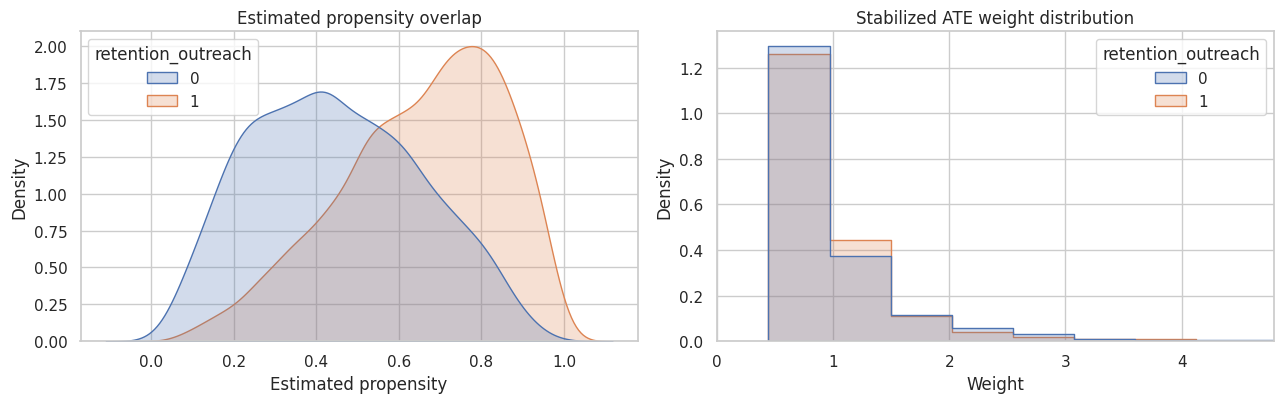

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.kdeplot(data=df, x='propensity_hat', hue='retention_outreach', common_norm=False, fill=True, alpha=0.25, ax=axes[0])
axes[0].set_title('Estimated propensity overlap')
axes[0].set_xlabel('Estimated propensity')

sns.histplot(data=df, x='ate_weight', hue='retention_outreach', bins=60, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_xlim(0, np.percentile(df['ate_weight'], 99.5))
axes[1].set_title('Stabilized ATE weight distribution')
axes[1].set_xlabel('Weight')
plt.tight_layout()
plt.show()

A propensity model can create new problems if overlap is weak. A few units with very large weights can dominate the estimate. That is why weight diagnostics belong next to the estimate.

Read the plot as a diagnostic for the workflow. The main question is what visible pattern would change the analysis in Propensity Model and Weights. Use the separation pattern to decide whether the rule can stay simple.


## 6. Balance Diagnostics

We compute standardized mean differences before and after weighting. For categorical variables, we one-hot encode levels and treat each level indicator as a covariate.

In [10]:
# Section focus: 6. Balance Diagnostics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def weighted_mean(x, w):
    """Carry out the weighted mean step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    w : object
        Observation weights used in a weighted calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the weighted mean calculation and reused by later cells.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w)
    if mask.sum() == 0 or w[mask].sum() == 0:
        return np.nan
    return np.sum(w[mask] * x[mask]) / np.sum(w[mask])


def weighted_var(x, w):
    """Carry out the weighted var step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    w : object
        Observation weights used in a weighted calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the weighted var calculation and reused by later cells.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w)
    if mask.sum() <= 1 or w[mask].sum() == 0:
        return np.nan
    mean = weighted_mean(x[mask], w[mask])
    return np.sum(w[mask] * (x[mask] - mean) ** 2) / np.sum(w[mask])


def smd_for_matrix(X, treatment, weights=None):
    """Carry out the smd for matrix step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    weights : object
        Observation weights used to emphasize rows in an estimator or summary.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    treatment = np.asarray(treatment)
    if weights is None:
        weights = np.ones(len(treatment))
    weights = np.asarray(weights, dtype=float)
    for col in X.columns:
        x = X[col].astype(float).to_numpy()
        treated = treatment == 1
        control = treatment == 0
        mt = weighted_mean(x[treated], weights[treated])
        mc = weighted_mean(x[control], weights[control])
        vt = weighted_var(x[treated], weights[treated])
        vc = weighted_var(x[control], weights[control])
        pooled_sd = np.sqrt((vt + vc) / 2) if np.isfinite(vt) and np.isfinite(vc) else np.nan
        smd = np.nan if pooled_sd == 0 or not np.isfinite(pooled_sd) else (mt - mc) / pooled_sd
        rows.append({'covariate': col, 'smd': smd, 'abs_smd': abs(smd) if np.isfinite(smd) else np.nan})
    return pd.DataFrame(rows)

X_balance = design_matrix(df, analysis_contract['allowed_covariates'], analysis_contract['categorical_covariates'])
unweighted_balance = smd_for_matrix(X_balance, df[analysis_contract['treatment']]).assign(stage='unweighted')
weighted_balance = smd_for_matrix(X_balance, df[analysis_contract['treatment']], df['ate_weight']).assign(stage='weighted')
balance_table = pd.concat([unweighted_balance, weighted_balance], ignore_index=True)
balance_summary = (
    balance_table
    .groupby('stage', as_index=False)
    .agg(max_abs_smd=('abs_smd', 'max'), mean_abs_smd=('abs_smd', 'mean'), covariates_over_0_10=('abs_smd', lambda s: int((s > 0.10).sum())), covariates_over_0_20=('abs_smd', lambda s: int((s > 0.20).sum())))
)
smart_display(balance_summary)

,stage,max_abs_smd,mean_abs_smd,covariates_over_0_10,covariates_over_0_20
0,unweighted,1.003192,0.325314,7,5
1,weighted,0.025871,0.013159,0,0


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Balance Diagnostics. A standout row deserves a second look before it becomes a conclusion.


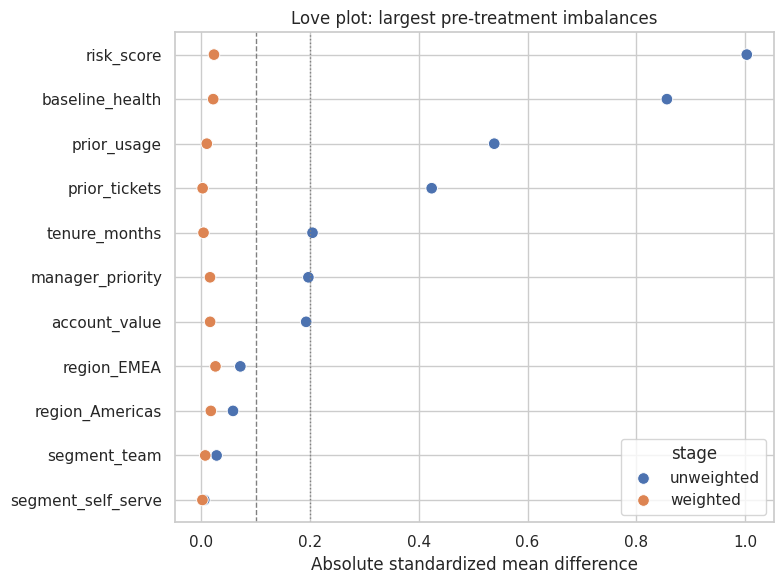

In [11]:
love_plot_data = (
    balance_table
    .pivot(index='covariate', columns='stage', values='abs_smd')
    .reset_index()
    .sort_values('unweighted', ascending=False)
    .head(18)
    .melt(id_vars='covariate', value_vars=['unweighted', 'weighted'], var_name='stage', value_name='abs_smd')
)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=love_plot_data, y='covariate', x='abs_smd', hue='stage', s=70, ax=ax)
ax.axvline(0.10, color='gray', linestyle='--', linewidth=1)
ax.axvline(0.20, color='gray', linestyle=':', linewidth=1)
ax.set_title('Love plot: largest pre-treatment imbalances')
ax.set_xlabel('Absolute standardized mean difference')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Balance improving after weighting is encouraging, but not enough. We still need to know whether the weights are stable and whether overlap is adequate.

This figure is meant to make the pattern visible. In Balance Diagnostics, the shape, separation, overlap, tail behavior, or clustering should be tied back to a modeling choice or guardrail. A decision workflow should use the visual pattern to decide where the model is credible and where the next diagnostic needs attention.


## 7. Overlap, Weight, and ESS Diagnostics

Effective sample size gives a practical sense of how much information remains after weighting. If the effective sample size collapses, the estimate may be driven by a small number of heavily weighted units.

In [12]:
# Section focus: 7. Overlap, Weight, and ESS Diagnostics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def effective_sample_size(weights):
    """Carry out the effective sample size step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    weights : object
        Observation weights used to emphasize rows in an estimator or summary.
    
    Returns
    -------
    object
        Intermediate result produced by the effective sample size calculation and reused by later cells.
    """
    weights = np.asarray(weights, dtype=float)
    weights = weights[np.isfinite(weights)]
    if len(weights) == 0 or np.sum(weights ** 2) == 0:
        return np.nan
    return (weights.sum() ** 2) / np.sum(weights ** 2)


def overlap_and_weight_diagnostics(df, contract, weight_col='ate_weight', propensity_col='propensity_hat'):
    """Carry out the overlap and weight diagnostics step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    weight_col : object
        Column containing observation weights for the weighted calculation.
    propensity_col : object
        Column name containing estimated treatment or assignment probabilities.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    t = df[contract['treatment']].eq(1)
    common_low = max(df.loc[t, propensity_col].min(), df.loc[~t, propensity_col].min())
    common_high = min(df.loc[t, propensity_col].max(), df.loc[~t, propensity_col].max())
    in_common = df[propensity_col].between(common_low, common_high)
    rows = [
        {'metric': 'estimated treatment rate', 'value': df[contract['treatment']].mean()},
        {'metric': 'common support lower bound', 'value': common_low},
        {'metric': 'common support upper bound', 'value': common_high},
        {'metric': 'share in common support', 'value': in_common.mean()},
        {'metric': 'share propensity < 0.05 or > 0.95', 'value': ((df[propensity_col] < 0.05) | (df[propensity_col] > 0.95)).mean()},
        {'metric': 'max stabilized weight', 'value': df[weight_col].max()},
        {'metric': 'p99 stabilized weight', 'value': df[weight_col].quantile(0.99)},
        {'metric': 'overall effective sample size', 'value': effective_sample_size(df[weight_col])},
        {'metric': 'treated effective sample size', 'value': effective_sample_size(df.loc[t, weight_col])},
        {'metric': 'control effective sample size', 'value': effective_sample_size(df.loc[~t, weight_col])},
        {'metric': 'overall ESS ratio', 'value': effective_sample_size(df[weight_col]) / len(df)},
    ]
    return pd.DataFrame(rows)

overlap_weight_report = overlap_and_weight_diagnostics(df, analysis_contract)
smart_display(overlap_weight_report)

,metric,value
0,estimated treatment rate,0.564231
1,common support lower bound,0.084063
2,common support upper bound,0.986363
3,share in common support,0.992885
4,share propensity < 0.05 or > 0.95,0.015962
5,max stabilized weight,31.954424
6,p99 stabilized weight,3.697411
7,overall effective sample size,3312.570926
8,treated effective sample size,2207.554090
9,control effective sample size,1203.275530


This turns a model result into a question about how the system should be used. The useful reading is which metric would change the action in Overlap, Weight, and ESS Diagnostics. The threshold choice is easier to defend once the operating priority is named.


In [13]:
weight_by_group = df.groupby('retention_outreach')['ate_weight'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).reset_index()
smart_display(weight_by_group)

,retention_outreach,count,mean,std,min,50%,90%,95%,99%,max
0,0,2266.0,1.001148,0.941070,0.445239,0.770428,1.662937,2.225649,3.813544,31.954424
1,1,2934.0,1.003970,0.576024,0.569996,0.825862,1.528558,1.951417,3.498572,6.711984


The key numbers are the p99 weight, ESS ratio, common-support share, and maximum weight together. Look at the p99 weight, ESS ratio, and common-support share together. A single high weight may be manageable; many high weights plus low ESS is a design warning.

Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Overlap, Weight, and ESS Diagnostics. A large number is less important than a row that changes the workflow.


## 8. Effect Estimate, Trimming, and Placebo Checks

Now we estimate the treatment effect using weighted least squares. We also compute a placebo effect on the pre-treatment outcome.

A useful report should not hide trimming decisions. We compare untrimmed and trimmed samples.

In [14]:
# Section focus: 8. Effect Estimate, Trimming, and Placebo Checks.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def weighted_effect(df, contract, outcome, weight_col='ate_weight'):
    """Carry out the weighted effect step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    weight_col : object
        Column containing observation weights for the weighted calculation.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    formula = f"{outcome} ~ {contract['treatment']}"
    fitted = smf.wls(formula, data=df, weights=df[weight_col]).fit(cov_type='HC3')
    estimate = fitted.params[contract['treatment']]
    se = fitted.bse[contract['treatment']]
    return {
        'outcome': outcome,
        'estimate': float(estimate),
        'robust_se': float(se),
        'ci_low': float(estimate - 1.96 * se),
        'ci_high': float(estimate + 1.96 * se),
        'rows': int(fitted.nobs),
    }


def evaluate_trim_rule(df, contract, lower=0.0, upper=1.0):
    """Evaluate trim rule for the 15. Automating Balance, Overlap, and Diagnostic Reports decision workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    lower : object
        Lower bound used in an interval, clipping rule, or plotted range.
    upper : object
        Upper bound used in an interval, clipping rule, or plotted range.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    trimmed = df[df['propensity_hat'].between(lower, upper)].copy()
    result = {
        'trim_rule': f'{lower:.2f}-{upper:.2f}',
        'rows': len(trimmed),
        'row_share': len(trimmed) / len(df),
    }
    if len(trimmed) == 0 or trimmed[contract['treatment']].nunique() < 2:
        return {**result, 'effect_estimate': np.nan, 'placebo_estimate': np.nan, 'max_abs_smd': np.nan, 'ess_ratio': np.nan, 'max_weight': np.nan}
    X_trim = design_matrix(trimmed, contract['allowed_covariates'], contract['categorical_covariates'])
    bal = smd_for_matrix(X_trim, trimmed[contract['treatment']], trimmed['ate_weight'])
    effect = weighted_effect(trimmed, contract, contract['outcome'])
    placebo = weighted_effect(trimmed, contract, contract['placebo_outcome'])
    ess_ratio = effective_sample_size(trimmed['ate_weight']) / len(trimmed)
    return {
        **result,
        'effect_estimate': effect['estimate'],
        'effect_se': effect['robust_se'],
        'placebo_estimate': placebo['estimate'],
        'placebo_se': placebo['robust_se'],
        'max_abs_smd': bal['abs_smd'].max(),
        'mean_abs_smd': bal['abs_smd'].mean(),
        'ess_ratio': ess_ratio,
        'max_weight': trimmed['ate_weight'].max(),
        'p99_weight': trimmed['ate_weight'].quantile(0.99),
    }

trim_grid = pd.DataFrame(
    [
        evaluate_trim_rule(df, analysis_contract, 0.00, 1.00),
        evaluate_trim_rule(df, analysis_contract, 0.01, 0.99),
        evaluate_trim_rule(df, analysis_contract, 0.05, 0.95),
        evaluate_trim_rule(df, analysis_contract, 0.10, 0.90),
    ]
)
smart_display(trim_grid)

,trim_rule,rows,row_share,effect_estimate,effect_se,placebo_estimate,placebo_se,max_abs_smd,mean_abs_smd,ess_ratio,max_weight,p99_weight
0,0.00-1.00,5200,1.000000,0.052512,0.018097,-0.003244,0.018300,0.025871,0.013159,0.637033,31.954424,3.697411
1,0.01-0.99,5200,1.000000,0.052512,0.018097,-0.003244,0.018300,0.025871,0.013159,0.637033,31.954424,3.697411
2,0.05-0.95,5117,0.984038,0.051187,0.016266,-0.003800,0.016716,0.024808,0.013088,0.719801,8.494666,3.694507
3,0.10-0.90,4860,0.934615,0.050333,0.015819,0.001695,0.016285,0.014742,0.007572,0.778400,5.589914,3.272988


These numbers translate model behavior into decision consequences. For Effect Estimate, Trimming, and Placebo Checks, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


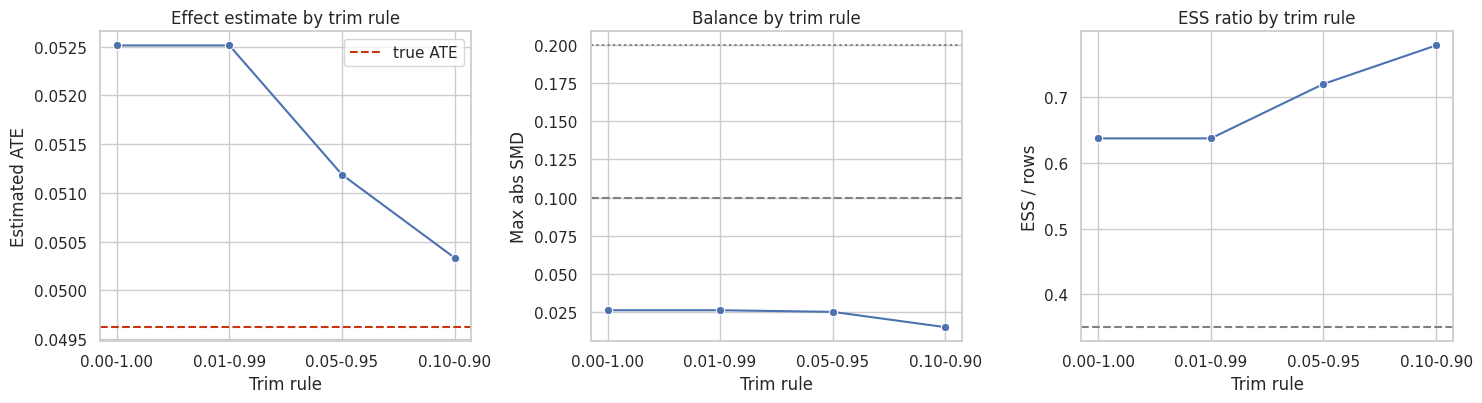

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.lineplot(data=trim_grid, x='trim_rule', y='effect_estimate', marker='o', ax=axes[0])
axes[0].axhline(truth['true_ate'], color='#CC3311', linestyle='--', label='true ATE')
axes[0].set_title('Effect estimate by trim rule')
axes[0].set_xlabel('Trim rule')
axes[0].set_ylabel('Estimated ATE')
axes[0].legend()

sns.lineplot(data=trim_grid, x='trim_rule', y='max_abs_smd', marker='o', ax=axes[1])
axes[1].axhline(0.10, color='gray', linestyle='--')
axes[1].axhline(0.20, color='gray', linestyle=':')
axes[1].set_title('Balance by trim rule')
axes[1].set_xlabel('Trim rule')
axes[1].set_ylabel('Max abs SMD')

sns.lineplot(data=trim_grid, x='trim_rule', y='ess_ratio', marker='o', ax=axes[2])
axes[2].axhline(analysis_contract['diagnostic_thresholds']['min_effective_sample_size_ratio'], color='gray', linestyle='--')
axes[2].set_title('ESS ratio by trim rule')
axes[2].set_xlabel('Trim rule')
axes[2].set_ylabel('ESS / rows')
plt.tight_layout()
plt.show()

Trimming is not a cosmetic tuning step. It changes the target population. If trimming removes many units, the report must say so. The resulting estimate may be more stable but less representative of the original eligible population.

These numbers translate model behavior into decision consequences. For Effect Estimate, Trimming, and Placebo Checks, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


## 9. Diagnostic Gates

We now turn the diagnostics into a structured decision. This is not a substitute for judgment, but it prevents us from burying warnings in plots.

In [16]:
# Section focus: 9. Diagnostic Gates.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def classify_gate(value, good_rule, caution_rule, labels=('pass', 'caution', 'fail')):
    """Carry out the classify gate step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    good_rule : object
        The good rule setting that controls the classify gate calculation in this notebook.
    caution_rule : object
        The caution rule setting that controls the classify gate calculation in this notebook.
    labels : object
        Observed or assigned labels used for evaluation.
    
    Returns
    -------
    object
        Intermediate result produced by the classify gate calculation and reused by later cells.
    """
    if good_rule(value):
        return labels[0]
    if caution_rule(value):
        return labels[1]
    return labels[2]


def build_diagnostic_gates(balance_summary, overlap_report, trim_grid, contract):
    """Build the diagnostic gates object used in the 15. Automating Balance, Overlap, and Diagnostic Reports analysis.
    
    Parameters
    ----------
    balance_summary : object
        The balance summary setting that controls the diagnostic gates calculation in this notebook.
    overlap_report : object
        The overlap report setting that controls the diagnostic gates calculation in this notebook.
    trim_grid : object
        The trim grid setting that controls the diagnostic gates calculation in this notebook.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    thresholds = contract['diagnostic_thresholds']
    weighted_balance_row = balance_summary.query("stage == 'weighted'").iloc[0]
    overlap_metrics = dict(zip(overlap_report['metric'], overlap_report['value']))
    untrimmed = trim_grid.query("trim_rule == '0.00-1.00'").iloc[0]
    gates = [
        {
            'gate': 'weighted balance',
            'metric': 'max_abs_smd',
            'value': weighted_balance_row['max_abs_smd'],
            'status': classify_gate(
                weighted_balance_row['max_abs_smd'],
                lambda x: x <= thresholds['max_abs_smd_good'],
                lambda x: x <= thresholds['max_abs_smd_caution'],
            ),
            'interpretation': 'Residual imbalance after weighting.',
        },
        {
            'gate': 'common support',
            'metric': 'share in common support',
            'value': overlap_metrics['share in common support'],
            'status': classify_gate(
                overlap_metrics['share in common support'],
                lambda x: x >= thresholds['min_common_support_share'],
                lambda x: x >= 0.70,
            ),
            'interpretation': 'Share of sample inside overlapping propensity range.',
        },
        {
            'gate': 'weight stability',
            'metric': 'max stabilized weight',
            'value': overlap_metrics['max stabilized weight'],
            'status': classify_gate(
                overlap_metrics['max stabilized weight'],
                lambda x: x <= thresholds['max_weight_caution'] / 2,
                lambda x: x <= thresholds['max_weight_caution'],
            ),
            'interpretation': 'Maximum stabilized weight.',
        },
        {
            'gate': 'effective sample size',
            'metric': 'overall ESS ratio',
            'value': overlap_metrics['overall ESS ratio'],
            'status': classify_gate(
                overlap_metrics['overall ESS ratio'],
                lambda x: x >= 0.55,
                lambda x: x >= thresholds['min_effective_sample_size_ratio'],
            ),
            'interpretation': 'Information retained after weighting.',
        },
        {
            'gate': 'placebo outcome',
            'metric': 'abs placebo estimate',
            'value': abs(untrimmed['placebo_estimate']),
            'status': classify_gate(
                abs(untrimmed['placebo_estimate']),
                lambda x: x <= thresholds['max_abs_placebo_effect_caution'] / 2,
                lambda x: x <= thresholds['max_abs_placebo_effect_caution'],
            ),
            'interpretation': 'Estimated effect on pre-treatment outcome.',
        },
    ]
    gate_df = pd.DataFrame(gates)
    if (gate_df['status'] == 'fail').any():
        recommendation = 'redesign or restrict target population before causal interpretation'
    elif (gate_df['status'] == 'caution').any():
        recommendation = 'proceed only with caution, sensitivity analysis, and explicit limitations'
    else:
        recommendation = 'diagnostics are acceptable for cautious estimation, subject to unmeasured confounding review'
    return gate_df, recommendation

gate_table, diagnostic_recommendation = build_diagnostic_gates(balance_summary, overlap_weight_report, trim_grid, analysis_contract)
smart_display(gate_table)

,gate,metric,value,status,interpretation
0,weighted balance,max_abs_smd,0.025871,pass,Residual imbalance after weighting.
1,common support,share in common support,0.992885,pass,Share of sample inside overlapping propensity range.
2,weight stability,max stabilized weight,31.954424,fail,Maximum stabilized weight.
3,effective sample size,overall ESS ratio,0.637033,pass,Information retained after weighting.
4,placebo outcome,abs placebo estimate,0.003244,pass,Estimated effect on pre-treatment outcome.


These numbers translate model behavior into decision consequences. For Diagnostic Gates, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


In [17]:
smart_display(diagnostic_recommendation)

'redesign or restrict target population before causal interpretation'

The recommendation is intentionally conservative. Diagnostics do not certify causality. They only tell us whether the measured-covariate design has obvious problems.

The value is in making the claim reviewable. For Diagnostic Gates, the important reading is the pattern across rows, the pattern across rows together with the largest values. A good workflow turns this pattern into a concrete follow-up action.


## 10. Build a Machine-Readable Diagnostic Report

Now we assemble the evidence into a report bundle. This is what the LLM will summarize.

In [18]:
# Section focus: 10. Build a Machine-Readable Diagnostic Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def dataframe_records(table, max_rows=30):
    """Carry out the dataframe records step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    table : object
        Tabular result used by this calculation or plot.
    max_rows : object
        Maximum number of rows shown in a rendered table or diagnostic display.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the dataframe records workflow for later analysis.
    """
    return json.loads(table.head(max_rows).to_json(orient='records', date_format='iso'))

report_bundle = {
    'analysis_contract': analysis_contract,
    'truth_available_only_because_synthetic': truth,
    'balance_summary': dataframe_records(balance_summary, max_rows=10),
    'largest_balance_issues': dataframe_records(
        balance_table.query("stage == 'weighted'").sort_values('abs_smd', ascending=False),
        max_rows=12,
    ),
    'overlap_and_weight_report': dataframe_records(overlap_weight_report, max_rows=20),
    'weight_by_group': dataframe_records(weight_by_group, max_rows=10),
    'trim_grid': dataframe_records(trim_grid, max_rows=10),
    'diagnostic_gates': dataframe_records(gate_table, max_rows=10),
    'diagnostic_recommendation': diagnostic_recommendation,
    'explicit_warnings': [
        'Good diagnostics do not prove exchangeability or eliminate unmeasured confounding.',
        'Trimming changes the target population and must be reported.',
        'A placebo check is supportive only when interpreted with domain knowledge.',
        'The LLM should summarize diagnostic evidence, not certify the causal effect.',
    ],
}

print(json.dumps(report_bundle, indent=2)[:5000])

{
  "analysis_contract": {
    "analysis_id": "retention_outreach_diagnostic_report_v1",
    "estimand": "ATE of retention_outreach on renewed_60d among eligible customers",
    "treatment": "retention_outreach",
    "outcome": "renewed_60d",
    "placebo_outcome": "renewed_prior_period",
    "allowed_covariates": [
      "segment",
      "region",
      "tenure_months",
      "prior_usage",
      "prior_tickets",
      "account_value",
      "baseline_health",
      "manager_priority",
      "risk_score"
    ],
    "categorical_covariates": [
      "segment",
      "region"
    ],
    "forbidden_variables": [
      "outreach_opened",
      "discount_used",
      "revenue_60d",
      "propensity_true",
      "p0_renewal",
      "p1_renewal",
      "true_individual_effect"
    ],
    "diagnostic_thresholds": {
      "max_abs_smd_good": 0.1,
      "max_abs_smd_caution": 0.2,
      "min_effective_sample_size_ratio": 0.35,
      "max_weight_caution": 20.0,
      "min_common_support_share":

A report bundle should be small enough to review and rich enough to support the conclusion. It should include the recommendation and the evidence behind the recommendation.

For Build a Machine-Readable Diagnostic Report, weak output is useful only if it tells us which part of the workflow needs a stronger check.


## 11. Shared Local LLM Runtime

We reuse the shared local model utilities so the model comparison is consistent with prior notebooks.

In [19]:
# Section focus: 11. Shared Local LLM Runtime.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def find_project_root(start=None):
    """Carry out the find project root step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    start : object
        Starting index, time, or location for the simulated event window.
    
    Returns
    -------
    object
        Intermediate result produced by the find project root calculation and reused by later cells.
    """
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local chat step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local chat calculation and reused by later cells.
    """
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 12. Structured AI Diagnostic Review

The model will summarize the diagnostic report. It must not certify the causal effect. It must name the diagnostics, the gate statuses, and the remaining limitations.

In [20]:
# Section focus: 12. Structured AI Diagnostic Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class DiagnosticReportReview(BaseModel):
    analysis_summary: str = Field(description='Brief summary of the design and estimand.')
    balance_assessment: list[str] = Field(description='Assessment of balance diagnostics.')
    overlap_assessment: list[str] = Field(description='Assessment of propensity overlap and common support.')
    weight_assessment: list[str] = Field(description='Assessment of weight stability and effective sample size.')
    placebo_assessment: list[str] = Field(description='Assessment of placebo or negative-control evidence.')
    recommendation: Literal['proceed', 'proceed_with_caution', 'redesign_or_restrict'] = Field(description='Recommended action based on diagnostics.')
    recommendation_rationale: list[str] = Field(description='Reasons supporting the recommendation.')
    limitations: list[str] = Field(description='Remaining limitations and assumptions not proven by diagnostics.')
    next_checks: list[str] = Field(description='Concrete next checks before reporting a causal estimate.')
    stakeholder_summary: str = Field(description='Plain-language summary for stakeholders.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the diagnostic review.')

REVIEW_SCALAR_FIELDS = ['analysis_summary', 'recommendation', 'stakeholder_summary', 'confidence']
REVIEW_LIST_FIELDS = [
    'balance_assessment',
    'overlap_assessment',
    'weight_assessment',
    'placebo_assessment',
    'recommendation_rationale',
    'limitations',
    'next_checks',
]
REVIEW_VALUE_ALIASES = {
    'recommendation': {
        'proceed': 'proceed',
        'go': 'proceed',
        'continue': 'proceed',
        'proceed_with_caution': 'proceed_with_caution',
        'proceedwithcaution': 'proceed_with_caution',
        'proceed_cautiously': 'proceed_with_caution',
        'caution': 'proceed_with_caution',
        'cautious': 'proceed_with_caution',
        'cautious_proceed': 'proceed_with_caution',
        'redesign_or_restrict': 'redesign_or_restrict',
        'redesignorrestrict': 'redesign_or_restrict',
        'redesign': 'redesign_or_restrict',
        'restrict': 'redesign_or_restrict',
        'redesign_restrict': 'redesign_or_restrict',
        'do_not_proceed': 'redesign_or_restrict',
    },
    'confidence': {
        'low': 'low',
        'medium': 'medium',
        'moderate': 'medium',
        'high': 'high',
    },
}

REVIEW_DEFAULTS = {
    'analysis_summary': '',
    'balance_assessment': [],
    'overlap_assessment': [],
    'weight_assessment': [],
    'placebo_assessment': [],
    'recommendation_rationale': [],
    'limitations': [],
    'next_checks': [],
    'stakeholder_summary': '',
    'confidence': 'medium',
}

REVIEW_ALIASES = {
    'summary': 'analysis_summary',
    'balance': 'balance_assessment',
    'overlap': 'overlap_assessment',
    'weights': 'weight_assessment',
    'placebo': 'placebo_assessment',
    'action': 'recommendation',
    'rationale': 'recommendation_rationale',
    'warnings': 'limitations',
    'diagnostics_to_run': 'next_checks',
}


def parse_diagnostic_review(raw_output):
    """Carry out the parse diagnostic review step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    result = parse_pydantic_output(
        raw_output,
        DiagnosticReportReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=REVIEW_DEFAULTS,
    )
    return result.parsed, result.json_text, result.notes

In [21]:
# Section focus: 12. Structured AI Diagnostic Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference diagnostic-report reviewer.\n'
    'Rules:\n'
    '- Use only the provided diagnostic report bundle.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Do not claim that diagnostics prove causality or eliminate unmeasured confounding.\n'
    '- Mention balance, overlap, weight stability, ESS, trimming, and placebo evidence when available.\n'
    '- Preserve the diagnostic recommendation unless you clearly justify a more cautious recommendation.\n'
    '- If any gate is caution or fail, do not recommend unconditional proceed.\n'
    '- Mention brittleness and rerun/model-output instability where appropriate.'
)


def build_review_prompt(bundle):
    """Build the review prompt object used in the 15. Automating Balance, Overlap, and Diagnostic Reports analysis.
    
    Parameters
    ----------
    bundle : object
        Grouped data, prompt material, or analysis artifacts passed between workflow steps.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the review prompt workflow.
    """
    schema_hint = {
        'analysis_summary': 'string',
        'balance_assessment': ['string'],
        'overlap_assessment': ['string'],
        'weight_assessment': ['string'],
        'placebo_assessment': ['string'],
        'recommendation': 'proceed | proceed_with_caution | redesign_or_restrict',
        'recommendation_rationale': ['string'],
        'limitations': ['string'],
        'next_checks': ['string'],
        'stakeholder_summary': 'string',
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a DiagnosticReportReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {json.dumps(schema_hint, indent=2)}

        Diagnostic report bundle:
        {json.dumps(bundle, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(report_bundle)
print(review_prompt[:3000])

Produce a DiagnosticReportReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {
  "analysis_summary": "string",
  "balance_assessment": [
    "string"
  ],
  "overlap_assessment": [
    "string"
  ],
  "weight_assessment": [
    "string"
  ],
  "placebo_assessment": [
    "string"
  ],
  "recommendation": "proceed | proceed_with_caution | redesign_or_restrict",
  "recommendation_rationale": [
    "string"
  ],
  "limitations": [
    "string"
  ],
  "next_checks": [
    "string"
  ],
  "stakeholder_summary": "string",
  "confidence": "low | medium | high"
}

        Diagnostic report bundle:
        {
  "analysis_contract": {
    "analysis_id": "retention_outreach_diagnostic_report_v1",
    "estimand": "ATE of retention_outreach on renewed_60d among eligible customers",
    "treatment": "retention_outreach",
    "outcome": "renewed_60d"

Read Structured AI Diagnostic Review as a draft from an unreliable assistant. Treat the checkable pieces as signal and the unsupported pieces as design feedback for the next run.


## 13. Run One Local Model

We start with the fast local model. A good answer should summarize the diagnostics and remain cautious about unmeasured confounding.

In [22]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    smart_display(Markdown('### Raw model output'))
    smart_display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "analysis_summary": "The analysis aims to estimate the Average Treatment Effect (ATE) of retention_outreach on renewed_60d among eligible customers, using allowed covariates and excluding forbidden variables.",
 "balance_assessment": [
 "Residual imbalance after weighting is present, as indicated by the maximum absolute standardized mean difference (SMD) of 0.025871 for the weighted data.",
 "The mean SMD across all covariates is 0.013159, with no covariates exceeding an SMD of 0.10."
 ],
 "overlap_assessment": [
 "The share of the sample within the common support is 0.992885, indicating good overlap between the treatment and control groups.",
 "The estimated treatment rate is 0.564231, and the share of propensity scores outside the [0.05, 0.95] range is 0.015962."
 ],
 "weight_assessment": [
 "The maximum stabilized weight is 31.9544, which exceeds the diagnostic threshold of 20.0, indicating potential weight instability.",
 "The overall effective sample size ratio is 0.637033, suggesting that information has been retained after weighting."
 ],
 "placebo_assessment": [
 "The placebo estimate is -0.003244, which is below the caution threshold of 0.04, indicating that the treatment effect is not driven by pre-treatment outcomes."
 ],
 "recommendation": "redesign_or_restrict_target_population_before_causal_interpretation",
 "recommendation_rationale": [
 "The diagnostic gates indicate that while there is good overlap and a placebo effect that does not exceed caution thresholds, the maximum stabilized weight is high, suggesting potential weight instability and brittleness in the model output.",
 "Further trimming or reweighting may be necessary to address the high maximum weight and ensure robustness of the results."
 ],
 "limitations": [
 "High maximum stabilized weight suggests potential weight instability and brittleness in the model output.",
 "The overall effective sample size ratio is below 0.7, indicating some loss of information after weighting."
 ],
 "next_checks": [
 "Consider further trimming or reweighting to reduce the maximum stabilized weight.",
 "Evaluate the impact of trimming on the treatment effect estimate and its standard error."
 ],
 "stakeholder_summary": "Stakeholders should be informed about the potential issues with weight instability and the need for further refinement of the target population before drawing causal conclusions.",
 "confidence": "medium"
}
```

Run One Local Model should show whether the model can follow the evidence without overclaiming.


In [23]:
if raw_review_output:
    try:
        diagnostic_review, diagnostic_review_json, review_parser_notes = parse_diagnostic_review(raw_review_output)
        single_model_parse_error = ''
        smart_display(Markdown('### Parsed diagnostic review'))
        smart_display(Markdown(f'```json\n{diagnostic_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        diagnostic_review = None
        diagnostic_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    diagnostic_review = None
    diagnostic_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.
ValueError('No valid DiagnosticReportReview found. Parser errors: ["Input should be \'proceed\', \'proceed_with_caution\' or \'redesign_or_restrict\'", \'1 validation error for DiagnosticReportReview\']')


The value is in making the design choices easy to inspect. For Run One Local Model, the important reading is the pattern across rows, the pattern across rows together with the largest values. The pattern is useful when it sharpens the next diagnostic.


## 14. Audit the AI Review

A good diagnostic review must not overclaim. It must mention the major evidence categories and respect caution or failure gates.

In [24]:
# Section focus: 14. Audit the AI Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def review_text(review):
    """Carry out the review text step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    review : object
        Reviewer text or model-generated critique being parsed, scored, or summarized.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the review text workflow.
    """
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    """Carry out the contains any step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    terms : object
        Search terms, concept terms, or model-output terms being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the contains any calculation and reused by later cells.
    """
    return any(term.lower() in text for term in terms)


def expected_recommendation_from_gates(gates):
    """Carry out the expected recommendation from gates step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    gates : object
        The gates setting that controls the expected recommendation from gates calculation in this notebook.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the expected recommendation from gates workflow.
    """
    statuses = set(gates['status'])
    if 'fail' in statuses:
        return 'redesign_or_restrict'
    if 'caution' in statuses:
        return 'proceed_with_caution'
    return 'proceed'

expected_recommendation = expected_recommendation_from_gates(gate_table)


def score_diagnostic_review(review, expected_recommendation):
    """Score diagnostic review for the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    review : object
        Reviewer text or model-generated critique being parsed, scored, or summarized.
    expected_recommendation : object
        Expected recommendation used as a reference answer in the evaluation.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    text = review_text(review)
    recommendation = review.recommendation if review is not None else ''
    checks = {
        'states estimand': analysis_contract['treatment'] in text and analysis_contract['outcome'] in text,
        'mentions balance': contains_any(text, ['balance', 'smd', 'standardized mean difference']),
        'mentions overlap/common support': contains_any(text, ['overlap', 'common support', 'propensity']),
        'mentions weights or ESS': contains_any(text, ['weight', 'effective sample size', 'ess']),
        'mentions placebo': contains_any(text, ['placebo', 'pre-treatment outcome', 'renewed_prior_period']),
        'mentions trimming/target population': contains_any(text, ['trim', 'target population', 'restrict']),
        'recommendation is not less cautious than gates': recommendation == expected_recommendation or (expected_recommendation == 'proceed' and recommendation in {'proceed', 'proceed_with_caution'}),
        'does not claim diagnostics prove causality': not contains_any(text, ['proves causality', 'proves the causal effect', 'eliminates unmeasured confounding']),
        'includes limitations': len(review.limitations) >= 2 if review is not None else False,
        'includes next checks': len(review.next_checks) >= 2 if review is not None else False,
        'mentions brittleness or caution': contains_any(text, ['caution', 'brittle', 'sensitivity', 'rerun', 'unstable']),
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit)

if diagnostic_review is not None:
    single_audit, single_score, single_max_score = score_diagnostic_review(diagnostic_review, expected_recommendation)
    print(f'Expected recommendation from gates: {expected_recommendation}')
    print(f'Score: {single_score}/{single_max_score}')
    smart_display(single_audit)
else:
    print('No diagnostic review to audit because live model execution was skipped or parsing failed.')

No diagnostic review to audit because live model execution was skipped or parsing failed.


The model is allowed to be more conservative than the gates. It should not be less conservative. If the gates say redesign, the LLM should not say proceed just because the estimate is statistically significant.

The metric result should be read as an operating tradeoff. In Audit the AI Review, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. Use the metric to sharpen the operational question: cost, risk, threshold, or action.


## 15. Optional All-Model Comparison

We now compare local models on two diagnostic reports: a moderate-overlap case and a poor-overlap case. The model must adapt its recommendation to the diagnostics.

The exact ranking can change across reruns and environments. That is expected. The durable lesson is that diagnostic interpretation must be evaluated against numeric gates, not vibes.

In [25]:
# Section focus: 15. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_report_bundle_for_scenario(case_id, targeting_strength, overlap_noise, seed):
    """Construct the report bundle for scenario helper used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    case_id : object
        Identifier used to track one scenario or experimental case in the results table.
    targeting_strength : object
        The targeting strength setting that controls the report bundle for scenario calculation in this notebook.
    overlap_noise : object
        The overlap noise setting that controls the report bundle for scenario calculation in this notebook.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    scenario_raw, scenario_truth = simulate_retention_diagnostics(
        n=4200,
        seed=seed,
        targeting_strength=targeting_strength,
        overlap_noise=overlap_noise,
    )
    propensity, _, _ = estimate_propensity(scenario_raw, analysis_contract)
    scenario_df = scenario_raw.assign(propensity_hat=propensity)
    tr = scenario_df[analysis_contract['treatment']].mean()
    scenario_df['ate_weight'] = np.where(
        scenario_df[analysis_contract['treatment']].eq(1),
        tr / scenario_df['propensity_hat'],
        (1 - tr) / (1 - scenario_df['propensity_hat']),
    )
    X = design_matrix(scenario_df, analysis_contract['allowed_covariates'], analysis_contract['categorical_covariates'])
    bal_un = smd_for_matrix(X, scenario_df[analysis_contract['treatment']]).assign(stage='unweighted')
    bal_w = smd_for_matrix(X, scenario_df[analysis_contract['treatment']], scenario_df['ate_weight']).assign(stage='weighted')
    bal = pd.concat([bal_un, bal_w], ignore_index=True)
    bal_summary = (
        bal.groupby('stage', as_index=False)
        .agg(max_abs_smd=('abs_smd', 'max'), mean_abs_smd=('abs_smd', 'mean'), covariates_over_0_10=('abs_smd', lambda s: int((s > 0.10).sum())), covariates_over_0_20=('abs_smd', lambda s: int((s > 0.20).sum())))
    )
    overlap_report = overlap_and_weight_diagnostics(scenario_df, analysis_contract)
    weights_by_group = scenario_df.groupby('retention_outreach')['ate_weight'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).reset_index()
    trims = pd.DataFrame(
        [
            evaluate_trim_rule(scenario_df, analysis_contract, 0.00, 1.00),
            evaluate_trim_rule(scenario_df, analysis_contract, 0.01, 0.99),
            evaluate_trim_rule(scenario_df, analysis_contract, 0.05, 0.95),
            evaluate_trim_rule(scenario_df, analysis_contract, 0.10, 0.90),
        ]
    )
    gates, rec = build_diagnostic_gates(bal_summary, overlap_report, trims, analysis_contract)
    bundle = {
        'case_id': case_id,
        'analysis_contract': analysis_contract,
        'truth_available_only_because_synthetic': scenario_truth,
        'balance_summary': dataframe_records(bal_summary, max_rows=10),
        'largest_balance_issues': dataframe_records(bal.query("stage == 'weighted'").sort_values('abs_smd', ascending=False), max_rows=12),
        'overlap_and_weight_report': dataframe_records(overlap_report, max_rows=20),
        'weight_by_group': dataframe_records(weights_by_group, max_rows=10),
        'trim_grid': dataframe_records(trims, max_rows=10),
        'diagnostic_gates': dataframe_records(gates, max_rows=10),
        'diagnostic_recommendation': rec,
        'explicit_warnings': report_bundle['explicit_warnings'],
    }
    return bundle, expected_recommendation_from_gates(gates)

moderate_bundle, moderate_expected = make_report_bundle_for_scenario('moderate_overlap', 1.0, 0.75, SEED + 1)
poor_bundle, poor_expected = make_report_bundle_for_scenario('poor_overlap', 2.4, 0.25, SEED + 2)

DIAGNOSTIC_EVAL_CASES = [
    {'case_id': 'moderate_overlap', 'bundle': moderate_bundle, 'expected_recommendation': moderate_expected},
    {'case_id': 'poor_overlap', 'bundle': poor_bundle, 'expected_recommendation': poor_expected},
]
[(case['case_id'], case['expected_recommendation']) for case in DIAGNOSTIC_EVAL_CASES]

[('moderate_overlap', 'proceed_with_caution'),
 ('poor_overlap', 'redesign_or_restrict')]

The evaluation in Optional All-Model Comparison is less about style and more about whether the causal reasoning is controllable.


In [26]:
# Section focus: 15. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'expected_recommendation', 'model_recommendation', 'status',
    'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'review_score', 'max_review_score',
    'review_score_share', 'error', 'raw_output_preview'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required DiagnosticReportReview JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.
    Use exact enum strings from the schema. Keep missing non-critical list fields as empty arrays.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_diagnostic_review():
    """Carry out the empty diagnostic review step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the empty diagnostic review workflow.
    """
    return DiagnosticReportReview(
        analysis_summary='',
        balance_assessment=[],
        overlap_assessment=[],
        weight_assessment=[],
        placebo_assessment=[],
        recommendation='proceed_with_caution',
        recommendation_rationale=[],
        limitations=[],
        next_checks=[],
        stakeholder_summary='',
        confidence='low',
    )


def parse_or_repair_review(raw_output, model_id):
    """Carry out the parse or repair review step used in the 15. Automating Balance, Overlap, and Diagnostic Reports workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_diagnostic_review(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_diagnostic_review(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_diagnostic_case(label, model_id, role, case):
    """Run the single model diagnostic case workflow for the 15. Automating Balance, Overlap, and Diagnostic Reports analysis.
    
    Parameters
    ----------
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    role : object
        Workflow role assigned to an agent, variable, or review component.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    prompt = build_review_prompt(case['bundle'])
    raw_output = ''
    max_score = score_diagnostic_review(empty_diagnostic_review(), case['expected_recommendation'])[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_review(raw_output, model_id)
        audit, score, max_score = score_diagnostic_review(parsed_result['parsed'], case['expected_recommendation'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'expected_recommendation': case['expected_recommendation'],
            'model_recommendation': parsed_result['parsed'].recommendation,
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'review_score': score,
            'max_review_score': max_score,
            'review_score_share': score / max_score if max_score else 0.0,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'expected_recommendation': case['expected_recommendation'],
            'model_recommendation': '',
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'review_score': 0,
            'max_review_score': max_score,
            'review_score_share': 0.0,
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    """Summarize model results for the 15. Automating Balance, Overlap, and Diagnostic Reports analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_review_score=('review_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_diagnostic_comparison(models_to_compare=MODELS_TO_COMPARE, cases=DIAGNOSTIC_EVAL_CASES):
    """Run the all model diagnostic comparison workflow for the 15. Automating Balance, Overlap, and Diagnostic Reports analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_diagnostic_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    diagnostic_model_summary, diagnostic_case_results = run_all_model_diagnostic_comparison()
else:
    diagnostic_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    diagnostic_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

smart_display(diagnostic_model_summary)

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,2,2,2,1.0,1.000000,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,2,2,1,1.0,1.000000,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,2,2,0,1.0,1.000000,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,2,2,0,1.0,1.000000,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,2,2,0,1.0,0.909091,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,2,2,0,1.0,0.909091,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,2,2,2,1.0,0.818182,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,2,1,0,0.5,0.454545,[wrong_field_type_or_schema]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,2,0,0,0.0,0.000000,"[invalid_json_or_truncated_output, missing_required_field]"


For Optional All-Model Comparison, look for the places where the model helps the analyst and the places where the analyst has to push back.


### Inspecting Case-Level Diagnostic Recommendations

This table shows whether model recommendations matched the diagnostic gates. A model that recommends unconditional proceed on a poor-overlap report should be treated as unsafe for this task.

In [27]:
diagnostic_case_results[[
    'label',
    'case_id',
    'expected_recommendation',
    'model_recommendation',
    'review_score_share',
    'status',
    'error_type',
]].sort_values(['label', 'case_id']).head(30)

,label,case_id,expected_recommendation,model_recommendation,review_score_share,status,error_type
14,Gemma 3 27B,moderate_overlap,proceed_with_caution,proceed_with_caution,1.000000,ok,
15,Gemma 3 27B,poor_overlap,redesign_or_restrict,redesign_or_restrict,1.000000,ok,
16,Llama 3.1 8B,moderate_overlap,proceed_with_caution,proceed_with_caution,1.000000,ok,
17,Llama 3.1 8B,poor_overlap,redesign_or_restrict,redesign_or_restrict,1.000000,ok,
10,Mistral 7B,moderate_overlap,proceed_with_caution,proceed_with_caution,0.909091,ok,
11,Mistral 7B,poor_overlap,redesign_or_restrict,redesign_or_restrict,0.909091,ok,
12,Mistral Small 24B,moderate_overlap,proceed_with_caution,proceed_with_caution,0.909091,ok,
13,Mistral Small 24B,poor_overlap,redesign_or_restrict,redesign_or_restrict,0.727273,ok,
8,Phi mini,moderate_overlap,proceed_with_caution,proceed_with_caution,1.000000,ok,
9,Phi mini,poor_overlap,redesign_or_restrict,redesign_or_restrict,1.000000,ok,


In Inspecting Case-Level Diagnostic Recommendations, a good answer gives the analyst something to verify instead of a confident conclusion to accept.


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. Diagnostic review failures are especially important because an invalid summary may hide design warnings from stakeholders.

In [28]:
failed_model_details = diagnostic_case_results.loc[
    ~diagnostic_case_results['schema_valid'],
    ['label', 'case_id', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
smart_display(failed_model_details)

,label,case_id,status,error_type,error,raw_output_preview
0,Qwen 0.5B,moderate_overlap,failed,invalid_json_or_truncated_output,"ValueError('No valid DiagnosticReportReview found. Parser errors: [\'Invalid JSON: expected value at line 1 column 1\', \'Expecting value: line 1 column 1 (...","```json\n{\n ""analysis_summary"": ""The retention outreach intervention has been analyzed for its impact on renewal rates among eligible customers. The analys..."
1,Qwen 0.5B,poor_overlap,failed,missing_required_field,"ValueError(""No valid DiagnosticReportReview found. Parser errors: ['Invalid JSON: expected value at line 1 column 1', 'Expecting value: line 1 column 1 (cha...","```json\n{\n ""analysis_summary"": ""The retention outreach intervention has an estimated treatment rate of 63.64%, which is significantly higher than the base..."
2,Qwen 7B,poor_overlap,failed,wrong_field_type_or_schema,"ValueError('No valid DiagnosticReportReview found. Parser errors: [""Input should be \'proceed\', \'proceed_with_caution\' or \'redesign_or_restrict\'"", \'1 ...","{\n ""analysis_summary"": ""The analysis aims to estimate the Average Treatment Effect (ATE) of retention_outreach on renewed_60d among eligible customers, usi..."


For Inspecting Failed Model Runs, a strong answer stays inside the evidence, names uncertainty, and keeps assumptions separate from prose.


### Interpreting Repair Counts

Repairs are diagnostic signals. They show how much cleanup was needed before the output became usable. A diagnostic-report assistant that often needs repair should stay firmly in analyst-review mode.

In [29]:
def summarize_repair_stages(case_results):
    """Summarize repair stages for the 15. Automating Balance, Overlap, and Diagnostic Reports analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(diagnostic_case_results)

,repair_stage,cases
2,none,10
3,parser,4
0,failed,3
1,model_retry,1


Read Interpreting Repair Counts with a simple standard. The generated text has to preserve the design, not replace it.


## 16. Reusable Diagnostic Report Checklist

Before reporting a causal estimate from observational adjustment or weighting, the analyst should be able to fill this checklist.

In [30]:
diagnostic_report_checklist = pd.DataFrame(
    [
        {'check': 'Estimand and target population stated', 'example': analysis_contract['estimand']},
        {'check': 'All adjusted covariates are pre-treatment', 'example': ', '.join(analysis_contract['allowed_covariates'])},
        {'check': 'Balance before and after adjustment reported', 'example': 'SMD table and Love plot'},
        {'check': 'Overlap/common support reported', 'example': 'Propensity distribution and common-support share'},
        {'check': 'Weight stability and ESS reported', 'example': 'Max weight, p99 weight, ESS ratio'},
        {'check': 'Trimming decisions reported', 'example': 'Trim grid with row share and target-population warning'},
        {'check': 'Placebo/negative-control evidence included when available', 'example': analysis_contract['placebo_outcome']},
        {'check': 'Diagnostic gates produce an action recommendation', 'example': diagnostic_recommendation},
        {'check': 'AI summary is audited', 'example': 'score_diagnostic_review'},
    ]
)
smart_display(diagnostic_report_checklist)

,check,example
0,Estimand and target population stated,ATE of retention_outreach on renewed_60d among eligible customers
1,All adjusted covariates are pre-treatment,"segment, region, tenure_months, prior_usage, prior_tickets, account_value, baseline_health, manager_priority, risk_score"
2,Balance before and after adjustment reported,SMD table and Love plot
3,Overlap/common support reported,Propensity distribution and common-support share
4,Weight stability and ESS reported,"Max weight, p99 weight, ESS ratio"
5,Trimming decisions reported,Trim grid with row share and target-population warning
6,Placebo/negative-control evidence included when available,renewed_prior_period
7,Diagnostic gates produce an action recommendation,redesign or restrict target population before causal interpretation
8,AI summary is audited,score_diagnostic_review


The reviewer should be able to point to the row that needs more evidence. For Reusable Diagnostic Report Checklist, the important reading is the pattern across rows, the pattern across rows together with the largest values. The workflow gains value when the pattern changes what gets inspected next.


## 17. Exercises

1. Tighten the `max_abs_smd_good` threshold from 0.10 to 0.05. How does the recommendation change?
2. Create a new scenario with worse overlap and compare the trim grid.
3. Add a negative-control outcome unrelated to retention and decide how it should enter the report.
4. Add a rule that fails the diagnostic gate if the p99 weight exceeds 10 even when max weight is acceptable.
5. Run the live all-model comparison and inspect whether any model recommends `proceed` for the poor-overlap case.
6. Remove the diagnostic gates from the prompt and rerun one model. Does the summary become more overconfident?

## Key Takeaways

Diagnostics are part of the causal result.

A strong automated diagnostic workflow has this shape:

1. State the analysis contract.
2. Estimate propensity using only pre-treatment covariates.
3. Report balance before and after adjustment.
4. Report overlap, weight stability, and effective sample size.
5. Compare trimming rules and state target-population implications.
6. Include placebo or negative-control checks when available.
7. Convert diagnostics into explicit gates.
8. Use AI to summarize, then audit that summary against the gates.

The practical rule is simple. never let an LLM summarize an observational estimate without giving it the diagnostic evidence and checking whether it respected the warnings.

## References

- Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika*, 70(1), 41-55. [https://doi.org/10.1093/biomet/70.1.41](https://doi.org/10.1093/biomet/70.1.41)
- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Imbens, G. W., & Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge University Press. [https://doi.org/10.1017/CBO9781139025751](https://doi.org/10.1017/CBO9781139025751)
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology*, 66(5), 688-701. [https://doi.org/10.1037/h0037350](https://doi.org/10.1037/h0037350)
